In [1]:
%cd ..

/data/projects/tcrio/tcrio


In [ ]:
from triassic.io.readers

In [2]:
from tcr_io.readers import AdaptiveReader, MixcrReader, ReaderFactory
from tcr_io.expressions import to_imgt, trim_junction_to_cdr3, is_valid_junction_aa, is_functional_tcr
from pathlib import Path
import polars as pl

In [3]:
f = Path("/data/datasets/public/harden_2015_psoriasis_trb_trg_skin/data/adaptive/*.tsv")
f = Path("/data/datasets/public/hamm_2020_adaptive_v4_control_repertoires_lung_cancer_melanoma/data/*.tsv")

f = Path("/data/datasets/public/immunecode_2020_covid_adaptive/data/raw/ImmuneCODE-Review-002/KH*.tsv")
f = Path("/data/datasets/public/alvares-beckenridge_2022_melanoma_brain_metastases_paired_blood/data/adaptive/*.tsv")
f = Path("/data/datasets/public/gil_2020_ebv_sorted/data/*.tsv")
f = Path("/data/datasets/temp_adaptive/extracted/*.tsv")
f = Path("/data/datasets/public/gil_2022_influenza_ebv/data/sampleExport.2026-02-05_14-23-11/*.tsv")

In [4]:
out_path = Path("/data/datasets/public/emerson_2017/data/processed/")
out_path.mkdir(exist_ok=True)

In [5]:
queries = []

f = Path("/data/datasets/public/emerson_2017/data/processed_files/P0*.tsv")

r = ReaderFactory()
for f_ in f.parent.glob(f.name):
    q = r.run(f_).filter(
        pl.col("junction").is_not_null() & is_valid_junction_aa(pl.col("junction_aa"))
    ).with_columns(
        is_functional_tcr()
    ).filter(
        pl.col("is_functional").struct.field("consensus")
    ).drop("is_functional").sink_parquet(
        out_path/(f_.stem + ".parquet"), lazy=True
    )

    queries.append(q)

In [6]:
pl.collect_all_async(queries, engine="streaming")

In [ ]:
pl.

In [ ]:
em = ReaderFactory().run(f).filter(
).with_columns(
    is_functional_tcr()
).filter(
    pl.col("is_functional").struct.field("consensus")
).drop("is_functional").collect(engine="streaming")

In [7]:
em.write_parquet(out_path, partition_by=["file"])

In [28]:
pl.read_parquet(out_path)

junction,junction_aa,v_call,j_call,duplicate_count,file,is_functional
str,str,str,str,i64,str,struct[5]
"""tgtgctagcagcccccagcgggacggggag…","""CASSPQRDGEQFF""","""TRBV7-7*01""","""TRBJ2-1*01""",2,"""P00001_clonotypes.tsv""","{true,true,true,true,true}"
"""tgtgctagcagcgctgggacagggtcggga…","""CASSAGTGSGKLFF""","""TRBV7-7*01""","""TRBJ1-4*01""",2,"""P00001_clonotypes.tsv""","{true,true,true,true,true}"
"""tgtgctagcagctccgcctcagggggtggg…","""CASSSASGGGAAVAYEQYF""","""TRBV7-7*01""","""TRBJ2-5*01""",2,"""P00001_clonotypes.tsv""","{true,true,true,true,true}"
"""tgtgctagcagcttaggtcggcggggggga…","""CASSLGRRGGFGEQFF""","""TRBV7-7*01""","""TRBJ2-1*01""",2,"""P00001_clonotypes.tsv""","{true,true,true,true,true}"
"""tgtgctagcagttccaccgggggcacagat…","""CASSSTGGTDTQYF""","""TRBV7-7*01""","""TRBJ2-3*01""",3,"""P00001_clonotypes.tsv""","{true,true,true,true,true}"
…,…,…,…,…,…,…
"""tgcagtgctccggcgggatcctcggggcag…","""CSAPAGSSGQFF""","""TRBV20-1*01""","""TRBJ2-1*01""",465,"""P00668_clonotypes.tsv""","{true,true,true,true,true}"
"""tgcagtgtatcgaaaggggacaggggacaa…","""CSVSKGDRGQTSF""","""TRBV20-1*01""","""TRBJ1-2*01""",564,"""P00668_clonotypes.tsv""","{true,true,true,true,true}"
"""tgtgccagcggattctcgacagggacgact…","""CASGFSTGTTEAFF""","""TRBV3-1*01""","""TRBJ1-1*01""",637,"""P00668_clonotypes.tsv""","{true,true,true,true,true}"


In [4]:
# f = Path("/data/projects/hla_models/tcr2hla_info/databases")

In [5]:
from tcrust.readers import AdaptiveReader

In [2]:
from pathlib import Path

In [5]:
Path("/data/test*").name

'test*'

In [6]:
df = AdaptiveReader().run(f)

In [9]:
df.filter(
    pl.col("junction").is_not_null(),
).sort(pl.col("duplicate_count")).collect(engine="streaming")

junction,junction_aa,v_call,j_call,duplicate_count,file
str,str,str,str,i64,str
"""tgtgccagcagctggggacagggggaaggc…","""CASSWGQGEGEQYF""","""TRBV11-3*01""","""TRBJ2-7*01""",1,"""KH20-11650_TCRB.tsv"""
"""tgtgccagcagccctgactctggggccaac…","""CASSPDSGANVLTF""","""TRBV11-3*01""","""TRBJ2-6*01""",1,"""KH20-11650_TCRB.tsv"""
"""tgtgccagcagttttggtacgggagacacc…","""CASSFGTGDTGELFF""","""TRBV12-1*01""","""TRBJ2-2*01""",1,"""KH20-11650_TCRB.tsv"""
"""tgtgccagcaggtcgaccggggtaccaaat…","""CASRSTGVPNQPQHF""","""TRBV28*01""","""TRBJ1-5*01""",1,"""KH20-11650_TCRB.tsv"""
"""tgtgccagcagtggggacagagataactat…","""CASSGDRDNYGYTF""","""TRBV12-1*01""","""TRBJ1-2*01""",1,"""KH20-11650_TCRB.tsv"""
…,…,…,…,…,…
"""tgtgccagcagcttaggggtcctggggact…","""CASSLGVLGTEAFF""","""TRBV7-6*01""","""TRBJ1-1*01""",147953,"""KH20-11647_TCRB.tsv"""
"""tgtgccagcagcttgggactagcggggcca…","""CASSLGLAGPDTQYF""","""TRBV7-3*01""","""TRBJ2-3*01""",152104,"""KHBR20-00179_TCRB.tsv"""
"""tgtgccagcagcttgggactagcggggcca…","""CASSLGLAGPDTQYF""","""TRBV7-3*01""","""TRBJ2-3*01""",161581,"""KHBR20-00137_TCRB.tsv"""


In [12]:
df.collect()

junction,junction_aa,v_call,j_call,duplicate_count,file
str,str,str,str,i64,str
"""ATTCTGGAGTCCGCCAGCACCAACCAGACA…","""CASKRDRVTEAFF""","""TCRBV28-01*01""","""TCRBJ01-01*01""",71,"""MS-111-BM3.tsv"""
"""TGACCAGTGCCCATCCTGAAGACAGCAGCT…",null,"""TCRBV20""","""TCRBJ01-01*01""",82,"""MS-111-BM3.tsv"""
"""GTGACCAGTGCCCATCCTGAAGACAGCAGC…","""CSASASGGSDTQYF""","""TCRBV20-01*04""","""TCRBJ02-03*01""",55,"""MS-111-BM3.tsv"""
"""NTGTCGGCTGCTCCCTCCCAGACATCTGTG…","""CASRRDGNSNQPQHF""","""TCRBV06-05*01""","""TCRBJ01-05*01""",28,"""MS-111-BM3.tsv"""
"""CAGCCCTCAGAACCCAGGGACTCAGCTGTG…","""CASSRALTGSDTQYF""","""TCRBV12""","""TCRBJ02-03*01""",34,"""MS-111-BM3.tsv"""
…,…,…,…,…,…
"""NNNNNNNTGTTGGCTGCTCCCTCCCAGACA…","""CASSHDRVSPLHF""","""TCRBV06-06*04""","""TCRBJ01-06*02""",1,"""MS-056-MT-01.tsv"""
"""GTTGGCTGCTCCCTCCCAGACATCTGTGTA…",null,"""TCRBV06-06*01""","""TCRBJ02-01*01""",1,"""MS-056-MT-01.tsv"""
"""CAGCGCACAGAGCAGGGGGACTCGGCCATG…","""CASSSTGTHQETQYF""","""TCRBV07-09*01""","""TCRBJ02-05*01""",1,"""MS-056-MT-01.tsv"""


In [6]:
pl.scan_parquet(f/"TRB_database.parquet").with_columns(
    to_imgt(pl.col("v_gene")),
    to_imgt(pl.col("j_gene")),
    is_valid_junction_aa(pl.col("CDR3")).alias("is_valid_junction")
).with_columns(
    is_functional_tcr(pl.col("v_gene"), pl.col("j_gene")).alias("is_functional")
).filter(
    pl.col("is_valid_junction") & pl.col("is_functional").struct.field("consensus")
).collect().write_parquet(f/"trb_processed.parquet")

In [11]:
m = AdaptiveReader()._read_multiple(f)

In [12]:
res = m.with_columns(
    to_imgt(pl.col("v_call")),
    to_imgt(pl.col("j_call")),
    trim_junction_to_cdr3(pl.col("junction"), pl.col("junction_aa")),
).with_columns(
    is_functional_tcr(
        pl.col("v_call"), pl.col("j_call"), organism="human"
    ).alias("is_functional")
).collect()

In [13]:
res

junction,junction_aa,v_call,j_call,duplicate_count,file,is_functional
str,str,str,str,i64,str,struct[5]
"""tgtgccagcaaaagagacagggttactgaa…","""CASKRDRVTEAFF""","""TRBV28*01""","""TRBJ1-1*01""",71,"""MS-111-BM3.tsv""","{true,true,true,true,true}"
null,null,"""TRBV20-1*01""","""TRBJ1-1*01""",82,"""MS-111-BM3.tsv""","{true,true,true,true,true}"
"""tgcagtgctagtgctagcggggggtcagat…","""CSASASGGSDTQYF""","""TRBV20-1*04""","""TRBJ2-3*01""",55,"""MS-111-BM3.tsv""","{true,true,true,true,true}"
"""tgtgccagcagaagggacgggaatagcaat…","""CASRRDGNSNQPQHF""","""TRBV6-5*01""","""TRBJ1-5*01""",28,"""MS-111-BM3.tsv""","{true,true,true,true,true}"
"""tgtgccagcagtagagcccttacgggatca…","""CASSRALTGSDTQYF""","""TRBV12-1*01""","""TRBJ2-3*01""",34,"""MS-111-BM3.tsv""","{true,false,true,true,false}"
…,…,…,…,…,…,…
"""tgtgccagcagtcatgacagggtttcaccc…","""CASSHDRVSPLHF""","""TRBV6-6*04""","""TRBJ1-6*02""",1,"""MS-056-MT-01.tsv""","{true,true,true,true,true}"
null,null,"""TRBV6-6*01""","""TRBJ2-1*01""",1,"""MS-056-MT-01.tsv""","{true,true,true,true,true}"
"""tgtgccagcagctccaccgggactcaccaa…","""CASSSTGTHQETQYF""","""TRBV7-9*01""","""TRBJ2-5*01""",1,"""MS-056-MT-01.tsv""","{true,true,true,true,true}"


In [11]:
res.filter(
    pl.col("is_functional").struct.field("consensus") == False
)

junction,junction_aa,v_call,j_call,duplicate_count,file,is_functional
str,str,str,str,i64,str,struct[5]
"""tgtgccagcagtagagcccttacgggatca…","""CASSRALTGSDTQYF""","""TRBV12-1*01""","""TRBJ2-3*01""",34,"""MS-111-BM3.tsv""","{true,false,true,true,false}"
"""tgtgccagcagctcaaaggcaggactcccg…","""CASSSKAGLPSAIQYF""","""TRBV21-1*01""","""TRBJ2-4*01""",22,"""MS-111-BM3.tsv""","{true,false,true,true,false}"
"""tgtgccagcagtttcaccgggggggcggat…","""CASSFTGGADTQYF""","""TRBV12-1*01""","""TRBJ2-3*01""",4,"""MS-111-BM3.tsv""","{true,false,true,true,false}"
"""tgtgccagcaggggaccgggacagttctat…","""CASRGPGQFYGYTF""","""TRBV12-1*01""","""TRBJ1-2*01""",3,"""MS-111-BM3.tsv""","{true,false,true,true,false}"
null,null,"""TRBV23-1*01""","""TRBJ1-1*01""",4,"""MS-111-BM3.tsv""","{true,false,true,true,false}"
…,…,…,…,…,…,…
null,null,"""TRBV23-1*01""","""TRBJ2-1*01""",1,"""MS-056-MT-01.tsv""","{true,false,true,true,false}"
"""tgtgccagcagtccaatagcgggggagcag…","""CASSPIAGEQFF""","""TRBV12-1*01""","""TRBJ2-1*01""",1,"""MS-056-MT-01.tsv""","{true,false,true,true,false}"
"""tgtgccagcagcaagggtggcaggcaaatc…","""CASSKGGRQICISILGLKEKLFF""","""TRBV21-1*01""","""TRBJ1-4*01""",1,"""MS-056-MT-01.tsv""","{true,false,true,true,false}"


In [9]:
res.with_columns(
    pl.col("is_functional").struct.field("functional").alias("functional")
)

StructFieldNotFoundError: functional

In [6]:
m.with_columns(
    # to_imgt(pl.col("v_call")).alias("v_call_imgt"),
    to_imgt(pl.col("j_call")).alias("j_call_imgt"),
    # to_imgt(pl.col("j_call")).alias("j_call_imgt"),
    # trim_junction_to_cdr3(pl.col("junction"), pl.col("junction_aa")),
).filter(
    # is_valid_junction_aa(pl.col("junction_aa")).alias("is_valid_junction_aa")
).group_by("j_call_imgt").agg(pl.len()).collect(engine="streaming")

j_call_imgt,len
str,u32
null,2
"""TRBJ2-6*01""",31003
"""TRBJ1-6*02""",47979
"""TRBJ1-3*01""",58135
"""TRBJ1-5*01""",128571
…,…
"""TRBJ2-2*01""",133948
"""TRBJ1-4*01""",75890
"""TRBJ1-2*01""",181965


In [29]:
res = _

In [30]:
pl.Config.set_tbl_rows(100)

polars.config.Config

In [34]:
res.filter(pl.col("v_call_imgt").str.contains("G", literal=False)).sort("len", descending=True)

v_call_imgt,len
str,u32
"""TRGV10*01""",4985
"""TRGV4*01""",1752
"""TRGV9*01""",1212
"""TRGV2*01""",946
"""TRGV8*01""",867
"""TRGV3*01""",715
"""TCRGV07-01*01""",619
"""TRGV5*01""",602
"""TRGV2*02""",374


In [31]:
res.sort("len", descending=True).filter(pl.col("v_call_imgt").str.contains("TCR[ABDG]", literal=False))

v_call_imgt,len
str,u32
"""TCRGV07-01*01""",619
"""TCRBV05-02*01""",15
"""TCRBV08-02*01""",10
"""TCRBVA-or09_02*01""",9
"""TCRBV22-01*01""",9
"""TCRGVA-01*01""",2
"""TCRGVB-01*01""",2
"""TCRGV06-01*01""",1


In [12]:
v_cts.tail(40)

v_call_imgt,count
str,u32
"""TRBV15*01""",48806
null,44718
"""TRBV7-9*05""",44623
"""TRBV12-2*01""",41869
"""TRBV10-1*03""",32731
"""TRBV1*01""",31816
"""TRBV7-8*02""",27176
"""TRBV30*02""",23732
"""TRBV6-7*01""",17650


In [10]:
from pathlib import Path

In [2]:
import os
# os.environ["POLARS_ENABLE_PLUGIN_LOGGING"] = "1"
# os.environ["POLARS_VERBOSE"] = "1"


In [6]:
import polars as pl

In [4]:
from triassic.constants.preprocessing import gene_map, IMGT
from tcrust import determine_reference_points, trim_nucleotide_to_cdr3, map_gene_alias

In [5]:
df = pl.scan_parquet("/data/datasets/public/ford_2022_sars-cov-2_vaccine/data/processed/*.parquet").head(5000).collect()

In [7]:
df = pl.DataFrame({
    "v_gene":["TCRBV12-03/12-04", "TCRBV12-03/12-04*01"]
})

In [8]:
df.with_columns(
    map_gene_alias(pl.col("v_gene")).alias("v_gene_mapped")
)

v_gene,v_gene_mapped
str,str
"""TCRBV12-03/12-04""","""TRBV12-1"""
"""TCRBV12-03/12-04*01""","""TRBV12-1*01"""


In [17]:
from triassic.constants.preprocessing import adaptive_to_imgt_human

adaptive_to_imgt_human_new = {}
for g,m in adaptive_to_imgt_human.items():
    if "-X" in g:
        adaptive_to_imgt_human_new[g.replace("-X", "")] = m.split("*")[0]
    adaptive_to_imgt_human_new[g] = m.split("*")[0]


aliases = pl.DataFrame({
    "from": list(adaptive_to_imgt_human_new.keys()),
    "to": list(adaptive_to_imgt_human_new.values())
}).with_columns(
    pl.col("to").replace("NA", None)
)

aliases_df = pl.read_csv("../reference/library-imgt/imgt.202614-2.parsed.tsv", separator="\t").filter(
    pl.col('organism') =="human"
).select(
    pl.col("gene")
).unique("gene").join(
    aliases.drop_nulls("to").group_by("to").agg("from"), left_on="gene", right_on="to", how="left"
).explode("from").rename({
    "gene": "imgt_gene",
}).select(["from", "imgt_gene"])

aliases_df.write_csv("gene_aliases.tsv", separator="\t")

In [4]:
from triassic.constants.base import AALPHABET

In [5]:
AALPHABET

'ARNDCQEGHILKMFPSTWYV'

In [20]:
filter_pat

'^C[VWNRDGHQTSIFEYAKPMCL]{5,28}(?:YV|F|W)$'

In [ ]:
valid_junction_filter = pl.col("junction_aa").str.contains(filter_pat)
adaptive_gene_mapper = [
    pl.col("v_resolved").str.split("*").list.get(0).replace_strict(adaptive_to_imgt_human_new, default=None).alias("v_call"),
    pl.col("j_resolved").str.split("*").list.get(0).replace_strict(adaptive_to_imgt_human_new, default=None).alias("j_call")
]

new_adaptive_gene_mapper = [
    map_gene_alias(pl.col("v_resolved")).alias("v_call"),
    map_gene_alias(pl.col("j_resolved")).alias("j_call")
]

cdr3_nucleotide_trimmer = trim_nucleotide_to_cdr3(pl.col("junction"), pl.col("junction_aa")).alias("junction")

In [9]:
p = Path("test.tsv.gz")

NameError: name 'Path' is not defined

In [ ]:
test_df = (
    pl.scan_csv("/data/datasets/public/immunecode_2020_covid_adaptive/data/raw/ImmuneCODE-Review-002/KH*.tsv", separator="\t", null_values=["na", "unknown", "no data", "unresolved"], include_file_paths="path")
    .rename({
        "templates":"duplicate_count",
        "amino_acid":"junction_aa",
        "rearrangement":"junction",   
    })
    .head(50_000_000)
    .select(["v_resolved", "j_resolved", "junction_aa", "duplicate_count", "junction"])
    .collect(engine="streaming")

    # .with_columns(
    #     reference_points = determine_reference_points(pl.col("junction"), pl.col("v_call"), pl.col("j_call"))
    # )
    # .show_graph(plan_stage="physical", engine="streaming")
)

In [37]:
test_df

v_resolved,j_resolved,junction_aa,duplicate_count,junction
str,str,str,i64,str
"""TCRBV20""","""TCRBJ01-03*01""","""CSARVRVGNTIYF""",848,"""ACAGTGACCAGTGCCCATCCTGAAGACAGC…"
"""TCRBV07-02""","""TCRBJ02-07*01""",null,181,"""TCCAGCGCACACAGCAGGAGGACTCGGCCG…"
"""TCRBV05-01*01""","""TCRBJ02-02*01""","""CASSFKKTGGNTGELFF""",95,"""TTGGAGCTGGGGGACTCGGCCCTTTATCTT…"
"""TCRBV30-01*01""","""TCRBJ01-05*01""","""CAWSTGTGEYQPQHF""",93,"""AAGAAGCTCCTTCTCAGTGACTCTGGCTTC…"
"""TCRBV04-03*01""","""TCRBJ01-02*01""",null,64,"""TACACACCCTGCAGCCAGAAGACTCGGCCC…"
…,…,…,…,…
"""TCRBV28-01*01""","""TCRBJ02-05*01""","""CASSLDRGYQETQYF""",1,"""GAGTCCGCCAGCACCAACCAGACATCTATG…"
"""TCRBV07-02""","""TCRBJ02-05*01""","""CASSLGGYQETQYF""",1,"""ATCCAGCGCACACAGCAGGAGGACTCGGCC…"
"""TCRBV29-01""","""TCRBJ02-05*01""","""CSVVRAVQETQYF""",1,"""ACTGTGAGCAACATGAGCCCTGAAGACAGC…"


In [44]:
%%timeit
test_df.with_columns(*new_adaptive_gene_mapper)

169 ms ± 3.02 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [45]:
%%timeit
test_df.with_columns(*adaptive_gene_mapper)

379 ms ± 22.4 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [46]:
from triassic.io.readers

SyntaxError: invalid syntax (4241973347.py, line 1)

In [ ]:
test_df = test_df.with_columns(
    pl.col("path").str.extract(r"/([^/]+)\.tsv", 1)
)

In [ ]:
subs = test_df.filter(
    pl.col("reference_points").struct.field("cdr3_end") == 45
).with_columns(
    pl.col("reference_points").struct.field("v_end_trimmed"),
    pl.col("reference_points").struct.field("d_begin_trimmed"),
    pl.col("reference_points").struct.field("d_end_trimmed"),
    pl.col("reference_points").struct.field("j_begin_trimmed"),

)

In [ ]:
import seaborn as sns

<Axes: xlabel='d_begin_trimmed', ylabel='d_end_trimmed'>

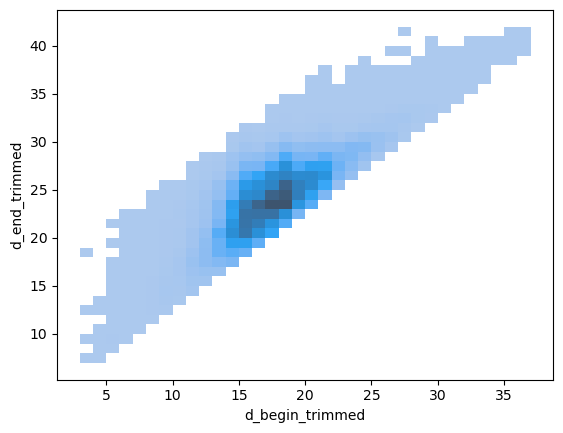

In [ ]:
sns.histplot(
    subs,
    x="d_begin_trimmed",
    y="d_end_trimmed",
    binwidth=1
)

In [ ]:
subs.sort(
    pl.col("v_end_trimmed")
)

junction,v_call,junction_aa,j_call,duplicate_count,path,filename,reference_points,v_end_trimmed,d_begin_trimmed,d_end_trimmed,j_begin_trimmed
str,str,str,str,i64,str,str,struct[9],u32,u32,u32,u32
"""tgcgccaggtcgctccagggggcaaccgac…","""TRBV2*01""","""CARSLQGATDNEQFF""","""TRBJ2-1*01""",1,"""/data/datasets/public/immuneco…","""KH20-09654_TCRB""","{2,15,23,28,17,11,23,23,45}",2,15,23,28
"""tgcgccagcagcttgggggggacaggggac…","""TRBV5-6*01""","""CASSLGGTGDYEQYF""","""TRBJ2-7*01""",1,"""/data/datasets/public/immuneco…","""KH20-09654_TCRB""","{2,18,28,29,16,18,30,26,45}",2,18,28,29
"""tgcgccagcagcccgggacaggacgggagg…","""TRBV6-5*01""","""CASSPGQDGRTEAFF""","""TRBJ1-1*01""",1,"""/data/datasets/public/immuneco…","""KH20-09654_TCRB""","{2,14,22,30,17,14,26,25,45}",2,14,22,30
"""tgcgccaccagtgggggacagggattcacc…","""TRBV24-1*01""","""CATSGGQGFTGELFF""","""TRBJ2-2*01""",1,"""/data/datasets/public/immuneco…","""KH20-09654_TCRB""","{2,14,23,26,18,14,26,22,45}",2,14,23,26
"""tgcgccagtaagaaggacaggcaaagctcc…","""TRBV19*01""","""CASKKDRQSSYEQYF""","""TRBJ2-7*01""",1,"""/data/datasets/public/immuneco…","""KH20-09654_TCRB""","{2,14,21,26,17,13,25,26,45}",2,14,21,26
…,…,…,…,…,…,…,…,…,…,…,…
"""tgtgccaccagtgatttgaggcaggggagg…","""TRBV24-1*01""","""CATSDLRQGRNEQFF""","""TRBJ2-1*01""",1,"""/data/datasets/public/immuneco…","""KH20-09712_TCRB""","{18,21,27,30,18,17,29,23,45}",18,21,27,30
"""tgtgccaccagtgatttggggacagccaaa…","""TRBV24-1*01""","""CATSDLGTAKETQYF""","""TRBJ2-5*01""",1,"""/data/datasets/public/immuneco…","""KH20-09712_TCRB""","{18,18,25,28,18,18,30,25,45}",18,18,25,28
"""tgtgccaccagtgatttgcccaggggaggc…","""TRBV24-1*01""","""CATSDLPRGGTEAFF""","""TRBJ1-1*01""",2,"""/data/datasets/public/immuneco…","""KH20-09712_TCRB""","{18,20,26,29,18,16,28,25,45}",18,20,26,29


In [ ]:
test_df

In [ ]:
%%timeit
test_df.with_columns(
        v_call = pl.col("v_resolved").str.split("*").list.get(0).replace_strict(adaptive_to_imgt_human_new, default=None),
        j_call = pl.col("j_resolved").str.split("*").list.get(0).replace_strict(adaptive_to_imgt_human_new, default=None)
    )

10.1 ms ± 151 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [ ]:
%%timeit
test_df.with_columns(
        junction = trim_nucleotide_to_cdr3(pl.col("rearrangement"), pl.col("junction_aa"))
    )

356 ms ± 31 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [ ]:
test_df = test_df.with_columns(
    junction = trim_nucleotide_to_cdr3(pl.col("rearrangement"), pl.col("junction_aa")),
    v_call = pl.col("v_resolved").str.split("*").list.get(0).replace_strict(adaptive_to_imgt_human_new, default=None),
    j_call = pl.col("j_resolved").str.split("*").list.get(0).replace_strict(adaptive_to_imgt_human_new, default=None)
)

In [ ]:
test_df = test_df.lazy()

In [ ]:
%%timeit
test_df.with_columns(
        reference_points = determine_reference_points(pl.col("junction"), pl.col("v_call"), pl.col("j_call"))
).collect()

3.61 s ± 11.1 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [ ]:
test_df = test_df.with_columns(
        reference_points = determine_reference_points(pl.col("junction"), pl.col("v_call"), pl.col("j_call"))
)

In [ ]:
test_df.with_columns(
    pl.col("reference_points").struct.field("v_end") - pl.col("reference_points").struct.field("v_end_trimmed")
)

CSE turned on because of struct expansion
CSE turned on because of struct expansion


rearrangement,v_resolved,j_resolved,junction_aa,duplicate_count,junction,v_call,j_call,reference_points,v_end
str,str,str,str,i64,str,str,str,struct[9],u32
"""ACAGTGACCAGTGCCCATCCTGAAGACAGC…","""TCRBV20""","""TCRBJ01-03*01""","""CSARVRVGNTIYF""",848,"""tgcagtgctagagtcagggttggaaacacc…","""TRBV20-1*01""","""TRBJ1-3*01""","{13,14,19,20,14,10,22,17,39}",1
"""TCCAGCGCACACAGCAGGAGGACTCGGCCG…","""TCRBV07-02""","""TCRBJ02-07*01""",null,181,null,"""TRBV7-2*01""","""TRBJ2-7*01""","{null,null,null,null,null,null,null,null,null}",null
"""TTGGAGCTGGGGGACTCGGCCCTTTATCTT…","""TCRBV05-01*01""","""TCRBJ02-02*01""","""CASSFKKTGGNTGELFF""",95,"""tgcgccagcagcttcaaaaagacagggggc…","""TRBV5-1*01""","""TRBJ2-2*01""","{14,20,30,30,16,18,30,28,51}",2
"""AAGAAGCTCCTTCTCAGTGACTCTGGCTTC…","""TCRBV30-01*01""","""TCRBJ01-05*01""","""CAWSTGTGEYQPQHF""",93,"""tgtgcctggagtaccgggacaggggaatat…","""TRBV30*01""","""TRBJ1-5*01""","{12,15,25,28,14,15,27,23,45}",2
"""TACACACCCTGCAGCCAGAAGACTCGGCCC…","""TCRBV04-03*01""","""TCRBJ01-02*01""",null,64,null,"""TRBV4-3*01""","""TRBJ1-2*01""","{null,null,null,null,null,null,null,null,null}",null
…,…,…,…,…,…,…,…,…,…
"""AAGCTCCTTCTCAGTGACTCTGGCTTCTAT…","""TCRBV30-01*01""","""TCRBJ02-05*01""","""CAWSASRSSGDETQYF""",1,"""tgtgcctggagtgccagtaggagtagcggg…","""TRBV30*01""","""TRBJ2-5*01""","{13,23,31,33,14,18,34,28,48}",1
"""ACTGTGACATCGGCCCAAAAGAACCCGACA…","""TCRBV19-01*01""","""TCRBJ02-05*01""","""CASSKGGLETQYF""",1,"""tgtgccagtagtaagggagggttggagacc…","""TRBV19*01""","""TRBJ2-5*01""","{13,14,21,24,17,5,21,19,39}",4
"""AAGATCCAGCCCTCAGAACCCAGGGACTCA…","""TCRBV12-03/12-04*01""","""TCRBJ02-05*01""","""CASSFSGVETQYF""",2,"""tgtgccagcagtttctctggggtggagacc…","""TRBV12-1*01""","""TRBJ2-5*01""","{11,18,22,24,17,12,24,19,39}",6


In [ ]:
test_df = test_df.with_columns(
    pl.col("reference_points").struct.field("duration_ns")
)

In [ ]:
import seaborn as sns

<Axes: xlabel='duration_ns', ylabel='Count'>

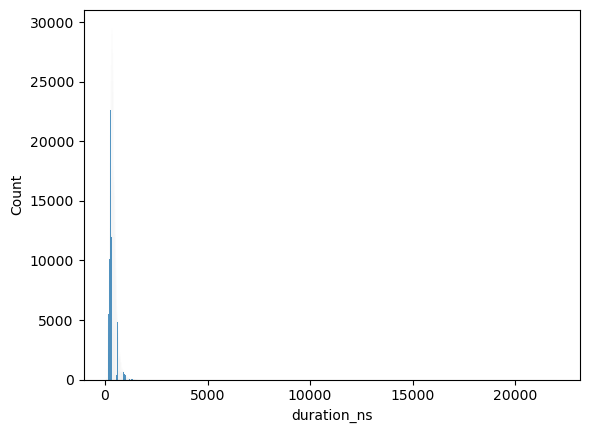

In [ ]:
sns.histplot(
    test_df,
    x="duration_ns"
)

In [ ]:
test_df = test_df.with_columns(long_time = pl.col("duration_ns")>3000).with_columns(
    pl.col("reference_points").struct.field("cdr3_end")
)

In [ ]:
test_df = test_df.with_columns(
    duration_ns_2 = determine_reference_points(pl.col("junction"), pl.col("v_call"), pl.col("j_call")).struct.field("duration_ns")
)

<Axes: xlabel='duration_ns', ylabel='duration_ns_2'>

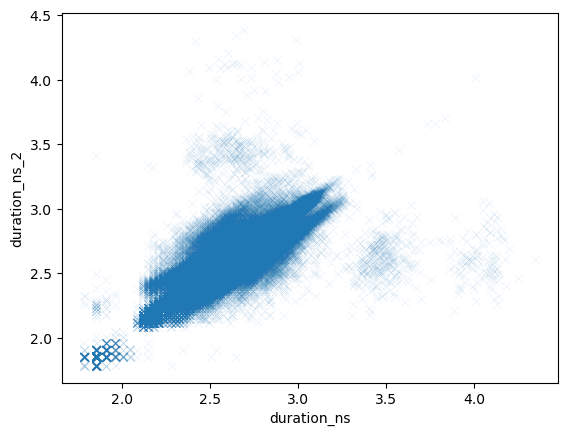

In [ ]:
sns.scatterplot(
    test_df.with_columns(
        pl.col("duration_ns").add(1).log(10),
        pl.col("duration_ns_2").add(1).log(10)
    ),
    x="duration_ns",
    y="duration_ns_2",
    marker="x",
    alpha=.1
)

In [ ]:
test_df.filter(pl.col("long_time"))

rearrangement,v_resolved,j_resolved,junction_aa,duplicate_count,junction,v_call,j_call,reference_points,duration_ns,long_time,cdr3_end,duration_ns_2
str,str,str,str,i64,str,str,str,struct[10],u64,bool,u32,u64
"""ACAGTGACCAGTGCCCATCCTGAAGACAGC…","""TCRBV20""","""TCRBJ01-03*01""","""CSARVRVGNTIYF""",848,"""tgcagtgctagagtcagggttggaaacacc…","""TRBV20-1*01""","""TRBJ1-3*01""","{13,14,19,20,14,10,22,17,39,10099}",10099,true,39,10280
"""TTGGAGCTGGGGGACTCGGCCCTTTATCTT…","""TCRBV05-01*01""","""TCRBJ02-02*01""","""CASSFKKTGGNTGELFF""",95,"""tgcgccagcagcttcaaaaagacagggggc…","""TRBV5-1*01""","""TRBJ2-2*01""","{14,20,30,30,16,18,30,28,51,5981}",5981,true,51,4539
"""AAGAAGCTCCTTCTCAGTGACTCTGGCTTC…","""TCRBV30-01*01""","""TCRBJ01-05*01""","""CAWSTGTGEYQPQHF""",93,"""tgtgcctggagtaccgggacaggggaatat…","""TRBV30*01""","""TRBJ1-5*01""","{12,15,25,28,14,15,27,23,45,5411}",5411,true,45,4528
"""CGGTCCACAAAGCTGGAGGACTCAGCCATG…","""TCRBV02-01""","""TCRBJ02-03*01""","""CASSRLAGGVDTQYF""",33,"""tgtgccagcagtagactagcggggggggta…","""TRBV2*01""","""TRBJ2-3*01""","{12,13,27,29,17,11,27,24,45,6813}",6813,true,45,5090
"""CAGCCCTCAGAACCCAGGGACTCAGCTGTG…","""TCRBV12""","""TCRBJ02-02*01""","""CASSTSGRAHGELFF""",5,"""tgtgccagcagtactagcgggagggctcac…","""TRBV12-1*01""","""TRBJ2-2*01""","{11,12,25,29,17,9,25,22,45,3727}",3727,true,45,2845
…,…,…,…,…,…,…,…,…,…,…,…,…
"""CGCACAGAGCGGGGGGACTCAGCCGTGTAT…","""TCRBV07-03*01""","""TCRBJ02-01*01""","""CASSLRPSLMNNEQFF""",1,"""tgtgccagcagcttaaggccatcgcttatg…","""TRBV7-3*01""","""TRBJ2-1*01""","{16,16,19,31,17,7,19,26,48,13165}",13165,true,48,420
"""AGCTCTCTGGAGCTGGGGGACTCAGCTTTG…","""TCRBV09-01*01""","""TCRBJ02-05*01""","""CASSVETWGGETQYF""",1,"""tgtgccagcagcgtagagacctggggggga…","""TRBV9*01""","""TRBJ2-5*01""","{16,22,29,29,16,13,29,25,45,12613}",12613,true,45,400
"""ACTCTGACTGTGAGCAACATGAGCCCTGAA…","""TCRBV29-01*01""","""TCRBJ01-01*01""","""CSVRRLTEAFF""",1,"""tgcagcgttcgaaggctgactgaagctttc…","""TRBV29-1*01""","""TRBJ1-1*01""","{9,12,15,18,14,7,19,13,33,11161}",11161,true,33,280


In [ ]:
test_df.with_columns(
        reference_points = determine_reference_points(pl.col("junction"), pl.col("v_call"), pl.col("j_call"))
    )

rearrangement,v_resolved,j_resolved,junction_aa,duplicate_count,junction,v_call,j_call,reference_points
str,str,str,str,i64,str,str,str,struct[9]
"""ACAGTGACCAGTGCCCATCCTGAAGACAGC…","""TCRBV20""","""TCRBJ01-03*01""","""CSARVRVGNTIYF""",848,"""tgcagtgctagagtcagggttggaaacacc…","""TRBV20-1*01""","""TRBJ1-3*01""","{13,14,19,20,14,10,22,17,39}"
"""TCCAGCGCACACAGCAGGAGGACTCGGCCG…","""TCRBV07-02""","""TCRBJ02-07*01""",null,181,null,"""TRBV7-2*01""","""TRBJ2-7*01""","{null,null,null,null,null,null,null,null,null}"
"""TTGGAGCTGGGGGACTCGGCCCTTTATCTT…","""TCRBV05-01*01""","""TCRBJ02-02*01""","""CASSFKKTGGNTGELFF""",95,"""tgcgccagcagcttcaaaaagacagggggc…","""TRBV5-1*01""","""TRBJ2-2*01""","{14,20,30,30,16,18,30,28,51}"
"""AAGAAGCTCCTTCTCAGTGACTCTGGCTTC…","""TCRBV30-01*01""","""TCRBJ01-05*01""","""CAWSTGTGEYQPQHF""",93,"""tgtgcctggagtaccgggacaggggaatat…","""TRBV30*01""","""TRBJ1-5*01""","{12,15,25,28,14,15,27,23,45}"
"""TACACACCCTGCAGCCAGAAGACTCGGCCC…","""TCRBV04-03*01""","""TCRBJ01-02*01""",null,64,null,"""TRBV4-3*01""","""TRBJ1-2*01""","{null,null,null,null,null,null,null,null,null}"
…,…,…,…,…,…,…,…,…
"""CGGTCCACAAAGCTGGAGGACTCAGCCATG…","""TCRBV02-01""","""TCRBJ01-01*01""","""CASRKDRGDLTEAFF""",4,"""tgtgccagcaggaaggacaggggggatctc…","""TRBV2*01""","""TRBJ1-1*01""","{11,14,24,29,17,13,25,25,45}"
"""AAGATCCGGTCCACAAAGCTGGAGGACTCA…","""TCRBV02-01""","""TCRBJ01-04*01""","""CASKEVLGSQLFF""",4,"""tgtgccagcaaggaggtattgggttcgcaa…","""TRBV2*01""","""TRBJ1-4*01""","{10,11,16,28,17,1,17,16,39}"
"""ATTCAGCGCACAGAGCAGGAGGACTCGGCC…","""TCRBV07-02""","""TCRBJ01-05*01""","""CASSVGPRFQPQHF""",1,"""tgtgccagcagcgtggggccccgctttcag…","""TRBV7-2*01""","""TRBJ1-5*01""","{12,14,19,26,17,7,19,20,42}"


In [ ]:
%%timeit -n 1
test_df.with_columns(
        reference_points = determine_reference_points(pl.col("junction"), pl.col("v_call"), pl.col("j_call"))
    )

KeyboardInterrupt: 

In [ ]:
    .with_columns(
        v_call = pl.col("v_resolved").str.split("*").list.get(0).replace_strict(adaptive_to_imgt_human_new, default=None),
        j_call = pl.col("j_resolved").str.split("*").list.get(0).replace_strict(adaptive_to_imgt_human_new, default=None)
    )
    .with_columns(
        junction = trim_nucleotide_to_cdr3(pl.col("rearrangement"), pl.col("junction_aa"))
    )
    .with_columns(
        reference_points = determine_reference_points(pl.col("junction"), pl.col("v_call"), pl.col("j_call"))
    )
    .select(["v_call", "j_call", "junction", "junction_aa", "duplicate_count"])
    .collect(engine="streaming")

In [ ]:
.select(
    ["rearrangement", "amino_acid"]
)

In [ ]:
test_df

rearrangement,extended_rearrangement,bio_identity,amino_acid,templates,frame_type,rearrangement_type,productive_frequency,cdr1_start_index,cdr1_rearrangement_length,cdr2_start_index,cdr2_rearrangement_length,cdr3_start_index,cdr3_length,v_index,n1_index,d_index,n2_index,j_index,v_deletions,n2_insertions,d3_deletions,d5_deletions,n1_insertions,j_deletions,chosen_j_allele,chosen_j_family,chosen_j_gene,chosen_v_allele,chosen_v_family,chosen_v_gene,d_allele,d_allele_ties,d_family,d_family_ties,d_gene,d_gene_ties,d_resolved,j_allele,j_allele_ties,j_family,j_family_ties,j_gene,j_gene_ties,j_resolved,v_allele,v_allele_ties,v_family,v_family_ties,v_gene,v_gene_ties,v_resolved
str,str,str,str,i64,str,str,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,str,i64,i64,str,i64,i64,str,str,str,str,str,str,i64,str,str,str,str,str,str,i64,str,str,str,str,str,str
"""ACAGTGACCAGTGCCCATCCTGAAGACAGC…",null,"""CSARVRVGNTIYF+TCRBV20-X+TCRBJ0…","""CSARVRVGNTIYF""",848,"""In""","""VDJ""",0.002374,null,null,null,null,null,39,42,55,56,61,62,1,1,3,4,1,3,null,null,null,null,null,null,1,null,"""TCRBD01""",null,"""TCRBD01-01""",null,"""TCRBD01-01*01""",1,null,"""TCRBJ01""",null,"""TCRBJ01-03""",null,"""TCRBJ01-03*01""",null,null,"""TCRBV20""",null,null,"""TCRBV20-01,TCRBV20-or09_02""","""TCRBV20"""
"""TCCAGCGCACACAGCAGGAGGACTCGGCCG…",null,"""X+TCRBV07-02+TCRBJ02-07""",null,181,"""Out""","""VDJ""",null,null,null,null,null,null,43,38,-1,54,59,65,1,null,null,7,6,3,null,null,null,null,null,null,1,null,"""TCRBD01""",null,"""TCRBD01-01""",null,"""TCRBD01-01*01""",1,null,"""TCRBJ02""",null,"""TCRBJ02-07""",null,"""TCRBJ02-07*01""",null,"""01,02""","""TCRBV07""",null,"""TCRBV07-02""",null,"""TCRBV07-02"""
"""TTGGAGCTGGGGGACTCGGCCCTTTATCTT…","""ATGGGCTCCAGGCTGCTCTGTTGGGTGCTG…","""CASSFKKTGGNTGELFF+TCRBV05-01+T…","""CASSFKKTGGNTGELFF""",95,"""In""","""VDJ""",0.000266,135,15,201,18,327,51,30,44,50,-1,60,2,6,null,2,null,2,1,"""TCRBJ02""",2,1,"""TCRBV05""",1,1,null,"""TCRBD01""",null,"""TCRBD01-01""",null,"""TCRBD01-01*01""",1,null,"""TCRBJ02""",null,"""TCRBJ02-02""",null,"""TCRBJ02-02*01""",1,null,"""TCRBV05""",null,"""TCRBV05-01""",null,"""TCRBV05-01*01"""
"""AAGAAGCTCCTTCTCAGTGACTCTGGCTTC…","""ATGCTCTGCTCTCTCCTTGCCCTTCTCCTG…","""CAWSTGTGEYQPQHF+TCRBV30-01+TCR…","""CAWSTGTGEYQPQHF""",93,"""In""","""VDJ""",0.00026,129,18,198,15,321,45,36,48,51,61,64,2,3,2,null,3,5,1,"""TCRBJ01""",5,1,"""TCRBV30""",1,1,null,"""TCRBD01""",null,"""TCRBD01-01""",null,"""TCRBD01-01*01""",1,null,"""TCRBJ01""",null,"""TCRBJ01-05""",null,"""TCRBJ01-05*01""",1,null,"""TCRBV30""",null,"""TCRBV30-01""",null,"""TCRBV30-01*01"""
"""TACACACCCTGCAGCCAGAAGACTCGGCCC…",null,"""X+TCRBV04-03+TCRBJ01-02""",null,64,"""Out""","""VDJ""",null,null,null,null,null,null,43,38,55,61,65,68,null,6,5,7,3,7,null,null,null,null,null,null,null,"""01,02""","""TCRBD02""",null,"""TCRBD02-01""",null,"""TCRBD02-01""",1,null,"""TCRBJ01""",null,"""TCRBJ01-02""",null,"""TCRBJ01-02*01""",1,null,"""TCRBV04""",null,"""TCRBV04-03""",null,"""TCRBV04-03*01"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""NNNNNNNNNNNNNTGTCGGCTGCTCCCTCC…",null,"""CASGFYNEQFF+TCRBV06-X+TCRBJ02-…","""CASGFYNEQFF""",1,"""In""","""VDJ""",0.000003,null,null,null,null,null,33,48,-1,57,60,62,8,null,8,1,2,3,null,null,null,null,null,null,null,null,null,"""TCRBD01,TCRBD02""",null,"""TCRBD01-01,TCRBD02-01""",null,1,null,"""TCRBJ02""",null,"""TCRBJ02-01""",null,"""TCRBJ02-01*01""",null,null,"""TCRBV06""",null,null,"""TCRBV06-02/06-03,TCRBV06-02""","""TCRBV06"""
"""GTTACATCGGGCCCAAAGAACCCGACAGCT…",null,"""CATLAGESYNEQFF+TCRBV19-01+TCRB…","""CATLAGESYNEQFF""",1,"""In""","""VDJ""",0.000003,null,null,null,null,null,42,39,46,49,58,60,10,3,2,5,2,1,null,null,null,null,null,null,2,null,"""TCRBD02""",null,"""TCRBD02-01""",null,"""TCRBD02-01*02""",1,null,"""TCRBJ02""",null,"""TCRBJ02-01""",null,"""TCRBJ02-01*01""",1,null,"""TCRBV19""",null,"""TCRBV19-01""",null,"""TCRBV19-01*01"""
"""CAG

In [ ]:
from triassic.io.readers import ImmuneCODEReader

In [ ]:
test_df

rearrangement,amino_acid
str,str
"""ACAGTGACCAGTGCCCATCCTGAAGACAGC…","""CSARVRVGNTIYF"""
"""TCCAGCGCACACAGCAGGAGGACTCGGCCG…",null
"""TTGGAGCTGGGGGACTCGGCCCTTTATCTT…","""CASSFKKTGGNTGELFF"""
"""AAGAAGCTCCTTCTCAGTGACTCTGGCTTC…","""CAWSTGTGEYQPQHF"""
"""TACACACCCTGCAGCCAGAAGACTCGGCCC…",null
…,…
"""GAGTCCGCCAGCACCAACCAGACATCTATG…","""CASSLDRGYQETQYF"""
"""ATCCAGCGCACACAGCAGGAGGACTCGGCC…","""CASSLGGYQETQYF"""
"""ACTGTGAGCAACATGAGCCCTGAAGACAGC…","""CSVVRAVQETQYF"""


In [ ]:
%%timeit -n 1
test_df.with_columns(
    trimmed_junction = trim_nucleotide_to_cdr3(pl.col("rearrangement"), pl.col("amino_acid"))
)

877 ms ± 76.4 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [ ]:
test_df = test_df.with_columns(
    trimmed_junction = trim_nucleotide_to_cdr3(pl.col("rearrangement"), pl.col("amino_acid")).str.to_lowercase()
)

In [ ]:
len(test_df)

1000000

In [ ]:
test_df.with_columns(
    trim_nucleotide_to_cdr3(pl.col("rearrangement"), pl.col("amino_acid")).str.to_lowercase().alias("trimmed_junction")
)

rearrangement,extended_rearrangement,bio_identity,amino_acid,templates,frame_type,rearrangement_type,productive_frequency,cdr1_start_index,cdr1_rearrangement_length,cdr2_start_index,cdr2_rearrangement_length,cdr3_start_index,cdr3_length,v_index,n1_index,d_index,n2_index,j_index,v_deletions,n2_insertions,d3_deletions,d5_deletions,n1_insertions,j_deletions,chosen_j_allele,chosen_j_family,chosen_j_gene,chosen_v_allele,chosen_v_family,chosen_v_gene,d_allele,d_allele_ties,d_family,d_family_ties,d_gene,d_gene_ties,d_resolved,j_allele,j_allele_ties,j_family,j_family_ties,j_gene,j_gene_ties,j_resolved,v_allele,v_allele_ties,v_family,v_family_ties,v_gene,v_gene_ties,v_resolved,trimmed_junction
str,str,str,str,i64,str,str,str,str,str,str,str,str,i64,i64,i64,i64,i64,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
"""AAGATCCAGCCTGCAGAGCTTGGGGACTCG…","""ATGAGCACCAGGCTTCTCTGCTGGATGGCC…","""CASSFGTGYEQYF+TCRBV11-01+TCRBJ…","""CASSFGTGYEQYF""",82445,"""In""","""VDJ""","""0.2299695400888135""","""135""","""15""","""201""","""18""","""330""",39,42,56,57,-1,66,"""3""","""1""","""3""","""no data""","""no data""","""4""","""01""","""TCRBJ02""","""07""","""01""","""TCRBV11""","""01""","""01""","""no data""","""TCRBD01""","""no data""","""TCRBD01-01""","""no data""","""TCRBD01-01*01""","""01""","""no data""","""TCRBJ02""","""no data""","""TCRBJ02-07""","""no data""","""TCRBJ02-07*01""","""01""","""no data""","""TCRBV11""","""no data""","""TCRBV11-01""","""no data""","""TCRBV11-01*01""","""tgtgccagcagcttcgggacagggtacgag…"
"""ATCCTGGAGTCGCCCAGCCCCAACCAGACC…","""ATGGGCCCCCAGCTCCTTGGCTATGTGGTC…","""CASSLTSLDEQFF+TCRBV27-01+TCRBJ…","""CASSLTSLDEQFF""",2295,"""In""","""VDJ""","""0.006401602213643363""","""135""","""15""","""201""","""18""","""327""",39,42,54,56,62,67,"""5""","""2""","""8""","""2""","""5""","""8""","""01""","""TCRBJ02""","""01""","""01""","""TCRBV27""","""01""","""unknown""","""01,02""","""TCRBD02""","""no data""","""TCRBD02-01""","""no data""","""TCRBD02-01""","""01""","""no data""","""TCRBJ02""","""no data""","""TCRBJ02-01""","""no data""","""TCRBJ02-01*01""","""01""","""no data""","""TCRBV27""","""no data""","""TCRBV27-01""","""no data""","""TCRBV27-01*01""","""tgtgccagcagtctgactagtttggatgag…"
"""ATCCAGCGCACACAGCAGGAGGACTCCGCC…","""ATGGGCACCAGGCTCCTCTGCTGGGTGGTC…","""CASSLPTGGETQYF+TCRBV07-08+TCRB…","""CASSLPTGGETQYF""",1218,"""In""","""VDJ""","""0.0033974516323388303""","""135""","""15""","""201""","""18""","""330""",42,39,54,58,65,66,"""2""","""4""","""1""","""8""","""1""","""5""","""01""","""TCRBJ02""","""05""","""01""","""TCRBV07""","""08""","""02""","""no data""","""TCRBD02""","""no data""","""TCRBD02-01""","""no data""","""TCRBD02-01*02""","""01""","""no data""","""TCRBJ02""","""no data""","""TCRBJ02-05""","""no data""","""TCRBJ02-05*01""","""01""","""no data""","""TCRBV07""","""no data""","""TCRBV07-08""","""no data""","""TCRBV07-08*01""","""tgtgccagcagcttacctacgggaggcgag…"
"""AGCCTGCAGAGCAGGGGGACTCGGCCGTGT…","""unknown""","""X+TCRBV12-02+TCRBJ02-02""","""na""",593,"""Out""","""VDJ""","""na""","""unknown""","""unknown""","""unknown""","""unknown""","""unknown""",46,35,42,49,57,61,"""10""","""7""","""2""","""2""","""4""","""3""","""no data""","""no data""","""no data""","""no data""","""no data""","""no data""","""01""","""no data""","""TCRBD01""","""no data""","""TCRBD01-01""","""no data""","""TCRBD01-01*01""","""01""","""no data""","""TCRBJ02""","""no data""","""TCRBJ02-02""","""no data""","""TCRBJ02-02*01""","""01""","""no data""","""TCRBV12""","""no data""","""TCRBV12-02""","""no data""","""TCRBV12-02*01""",null
"""NNNNNNNNNNTGTCGGCTGCTCCCTCCCAG…","""ATGAGCATCGGCCTCCTGTGCTGTGCAGCC…","""CASSPTGTEAFF+TCRBV06-05+TCRBJ0…","""CASSPTGTEAFF""",618,"""In""","""VDJ""","""0.0017238301385758598""","""135""","""15""","""201""","""18""","""327""",36,45,56,60,-1,66,"""6""","""4""","""3""","""3""","""no data""","""5""","""01""","""TCRBJ01""","""01""",

In [ ]:
pl.scan_csv("/data/datasets/public/pogorelyy_2019_ALICE_sample_data/data/Pogorelyy_YF/raw/*.tsv", separator="\t").head(10).collect()

Rank,Read.count,Read.proportion,CDR3.nucleotide.sequence,CDR3.amino.acid.sequence,bestVGene,bestJGene
i64,i64,f64,str,str,str,str
0,2454,0.002817,"""TGTGCCAGCAGCAACAGCGATAGGACGTAC…","""CASSNSDRTYGDNEQFF""","""TRBV6-3""","""TRBJ2-1"""
1,1915,0.002199,"""TGTGCCACCAGTTCCGTACTAACCCAACAA…","""CATSSVLTQQETQYF""","""TRBV24-1""","""TRBJ2-5"""
2,1369,0.001572,"""TGTGCCAGCAGTTCCCGAGGACTAGCGAAT…","""CASSSRGLANTQYF""","""TRBV12-4""","""TRBJ2-3"""
3,1255,0.001441,"""TGTGCCAGCAGCTTAGGGACAGCGTTGAAC…","""CASSLGTALNTEAFF""","""TRBV7-8""","""TRBJ1-1"""
4,1152,0.001323,"""TGTGCCAGCAGCCGCCGCCACCTAGGGAAC…","""CASSRRHLGNTGELFF""","""TRBV7-2""","""TRBJ2-2"""
5,1099,0.001262,"""TGTGCCAGCAGTGAGGGACGCAGCAATCAG…","""CASSEGRSNQPQHF""","""TRBV2""","""TRBJ1-5"""
6,1007,0.001156,"""TGCAGCGTTGTAGGCGCGGACACCTACGAG…","""CSVVGADTYEQYF""","""TRBV29-1""","""TRBJ2-7"""
7,831,0.000954,"""TGTGCCAGCAGTCCTAGCACAGATACGCAG…","""CASSPSTDTQYF""","""TRBV27""","""TRBJ2-3"""
8,788,0.000905,"""TGCAGTGCTAAGGGCCAGCGAGGGGGAGGA…","""CSAKGQRGGGYEQYF""","""TRBV20-1""","""TRBJ2-7"""


In [ ]:
df = df.with_columns(
    pl.col("v_call").replace("TRBV6-5*01", "TRBV6-5*100")
)

In [ ]:
df.with_columns(
    reference_points = determine_reference_points(
        pl.col("junction"),
        pl.col("v_call"),
        pl.col("j_call")
    )
)

junction,v_gene,junction_aa,j_gene,duplicate_count,v_call,j_call,repertoire_id,patient_id,reference_points
str,str,str,str,i64,str,str,str,str,struct[9]
"""tgtgccagcagcccgacaggggtcgggcag…","""TRBV6-5""","""CASSPTGVGQPQHF""","""TRBJ1-5""",1898,"""TRBV6-5*100""","""TRBJ1-5*01""","""514_1""","""514""","{null,null,null,null,null,null,null,null,null}"
"""tgtgccagctatgacaccagggaggtagaa…","""TRBV5-6""","""CASYDTREVEAFF""","""TRBJ1-1""",1646,"""TRBV5-6*01""","""TRBJ1-1*01""","""514_1""","""514""","{9,19,25,27,16,10,26,19,39}"
"""tgtgccaccagccgctatagcggggagacc…","""TRBV15""","""CATSRYSGETQYF""","""TRBJ2-5""",1617,"""TRBV15*01""","""TRBJ2-5*01""","""514_1""","""514""","{12,17,24,24,17,12,28,19,39}"
"""tgtgccagcagcttcgggggggcaaatcag…","""TRBV5-6""","""CASSFGGANQPQHF""","""TRBJ1-5""",1079,"""TRBV5-6*01""","""TRBJ1-5*01""","""514_1""","""514""","{14,14,22,24,16,6,22,20,42}"
"""tgtgccagcacccgggggacaggggatggc…","""TRBV2""","""CASTRGTGDGYTF""","""TRBJ1-2""",755,"""TRBV2*01""","""TRBJ1-2*01""","""514_1""","""514""","{10,15,25,25,17,15,27,19,39}"
…,…,…,…,…,…,…,…,…,…
"""tgtgccagcagcccagccgcctcctctgga…","""TRBV11-2""","""CASSPAASSGNTIYF""","""TRBJ1-3""",2,"""TRBV11-2*01""","""TRBJ1-3*01""","""514_1""","""514""","{12,13,16,23,17,9,21,23,45}"
"""tgtgccagcagcgcctggagcggggcgacc…","""TRBV9""","""CASSAWSGATYEQYF""","""TRBJ2-7""",2,"""TRBV9*01""","""TRBJ2-7*01""","""514_1""","""514""","{13,18,25,28,16,12,28,26,45}"
"""tgtgccagcagcgcctggactagcgggcac…","""TRBV9""","""CASSAWTSGHTGELFF""","""TRBJ2-2""",2,"""TRBV9*01""","""TRBJ2-2*01""","""514_1""","""514""","{13,16,27,28,16,15,31,25,48}"


In [ ]:
import os

In [ ]:
df = df.with_columns(
    chain = pl.col("v_gene").str.slice(0, 3)
)

In [ ]:
df["chain"].value_counts()

chain,count
str,u32
"""TRB""",1000000


In [ ]:
%%timeit
df.with_columns(
    reference_points = determine_reference_points(
        pl.col('junction'),
        pl.col("v_gene").add("*01"),
        pl.col("j_gene").add("*01"),
    )
)

1.41 s ± 53 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [ ]:
df = df.with_columns(
    reference_points = determine_reference_points(
        pl.col('junction'),
        pl.col("v_gene").add("*01"),
        pl.col("j_gene").add("*01"),
    )
)

In [ ]:
df

junction,v_gene,junction_aa,j_gene,duplicate_count,v_call,j_call,repertoire_id,patient_id,reference_points
str,str,str,str,i64,str,str,str,str,struct[9]
"""tgtgccagcagcccgacaggggtcgggcag…","""TRBV6-5""","""CASSPTGVGQPQHF""","""TRBJ1-5""",1898,"""TRBV6-5*01""","""TRBJ1-5*01""","""514_1""","""514""","{11,14,22,27,17,12,24,20,42}"
"""tgtgccagctatgacaccagggaggtagaa…","""TRBV5-6""","""CASYDTREVEAFF""","""TRBJ1-1""",1646,"""TRBV5-6*01""","""TRBJ1-1*01""","""514_1""","""514""","{9,19,25,27,16,10,26,19,39}"
"""tgtgccaccagccgctatagcggggagacc…","""TRBV15""","""CATSRYSGETQYF""","""TRBJ2-5""",1617,"""TRBV15*01""","""TRBJ2-5*01""","""514_1""","""514""","{12,17,24,24,17,12,28,19,39}"
"""tgtgccagcagcttcgggggggcaaatcag…","""TRBV5-6""","""CASSFGGANQPQHF""","""TRBJ1-5""",1079,"""TRBV5-6*01""","""TRBJ1-5*01""","""514_1""","""514""","{14,14,22,24,16,6,22,20,42}"
"""tgtgccagcacccgggggacaggggatggc…","""TRBV2""","""CASTRGTGDGYTF""","""TRBJ1-2""",755,"""TRBV2*01""","""TRBJ1-2*01""","""514_1""","""514""","{10,15,25,25,17,15,27,19,39}"
…,…,…,…,…,…,…,…,…,…
"""tgtgccagtagtagcgggggtctttggaca…","""TRBV19""","""CASSSGGLWTDTQYF""","""TRBJ2-3""",1,"""TRBV19*01""","""TRBJ2-3*01""","""836_4""","""836""","{13,13,20,27,17,6,22,24,45}"
"""tgtgccagtagtagcgggtggagctcctac…","""TRBV19""","""CASSSGWSSYNEQFF""","""TRBJ2-1""",1,"""TRBV19*01""","""TRBJ2-1*01""","""836_4""","""836""","{13,13,18,23,17,6,22,23,45}"
"""tgtgccagtagtagcgttcgacgaaaagaa…","""TRBV19""","""CASSSVRRKEANYGYTF""","""TRBJ1-2""",1,"""TRBV19*01""","""TRBJ1-2*01""","""836_4""","""836""","{13,19,22,31,17,17,29,31,51}"


In [ ]:
df.with_columns(
    jlen = pl.col("junction").str.len_chars()
)

junction,v_gene,junction_aa,j_gene,duplicate_count,v_call,j_call,repertoire_id,patient_id,reference_points,jlen
str,str,str,str,i64,str,str,str,str,struct[9],u32
"""tgtgccagcagcccgacaggggtcgggcag…","""TRBV6-5""","""CASSPTGVGQPQHF""","""TRBJ1-5""",1898,"""TRBV6-5*01""","""TRBJ1-5*01""","""514_1""","""514""","{11,14,22,27,17,12,24,20,42}",42
"""tgtgccagctatgacaccagggaggtagaa…","""TRBV5-6""","""CASYDTREVEAFF""","""TRBJ1-1""",1646,"""TRBV5-6*01""","""TRBJ1-1*01""","""514_1""","""514""","{9,19,25,27,16,10,26,19,39}",39
"""tgtgccaccagccgctatagcggggagacc…","""TRBV15""","""CATSRYSGETQYF""","""TRBJ2-5""",1617,"""TRBV15*01""","""TRBJ2-5*01""","""514_1""","""514""","{12,17,24,24,17,12,28,19,39}",39
"""tgtgccagcagcttcgggggggcaaatcag…","""TRBV5-6""","""CASSFGGANQPQHF""","""TRBJ1-5""",1079,"""TRBV5-6*01""","""TRBJ1-5*01""","""514_1""","""514""","{14,14,22,24,16,6,22,20,42}",42
"""tgtgccagcacccgggggacaggggatggc…","""TRBV2""","""CASTRGTGDGYTF""","""TRBJ1-2""",755,"""TRBV2*01""","""TRBJ1-2*01""","""514_1""","""514""","{10,15,25,25,17,15,27,19,39}",39
…,…,…,…,…,…,…,…,…,…,…
"""tgtgccagcagccccgggacagtgtttccc…","""TRBV27""","""CASSPGTVFPYEQYF""","""TRBJ2-7""",1,"""TRBV27*01""","""TRBJ2-7*01""","""586_3""","""586""","{11,15,22,28,17,15,27,26,45}",45
"""tgtgccagcagccccgggacagttagcaca…","""TRBV5-6""","""CASSPGTVSTDTQYF""","""TRBJ2-3""",1,"""TRBV5-6*01""","""TRBJ2-3*01""","""586_3""","""586""","{12,15,22,24,16,15,27,24,45}",45
"""tgtgccagcagccccgggacagttcttagc…","""TRBV7-8""","""CASSPGTVLSNQPQHF""","""TRBJ1-5""",1,"""TRBV7-8*01""","""TRBJ1-5*01""","""586_3""","""586""","{12,15,22,26,17,15,27,26,48}",48


In [ ]:
%%timeit
df.with_columns(
    d_seg = get_most_likely_d_segment_for_human(pl.col("junction"))
)

173 ms ± 2.17 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [ ]:
%%timeit
df.with_columns(
    d_seg = get_most_likely_d_segment_for_human_aho(pl.col("junction"))
)

23.3 ms ± 120 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [ ]:
%%timeit
df.with_columns(
    d_seg = get_most_likely_d_segment_struct_for_human_polars_new(pl.col("junction"))
)

27.5 ms ± 127 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [ ]:
df[0, "junction"]

'tgtgccagcagcccgacaggggtcgggcagccccagcatttt'

In [ ]:
from triassic.constants.junction import analyze_junctions

In [ ]:
analyze_junctions(df.head(10).to_pandas())

,junction,junction_aa,v_call,j_call,organism,chain,v_end_trimmed,d_begin_trimmed,d_end_trimmed,j_begin_trimmed,has_d_segment,v_end,d_begin,d_end,j_begin,germline_v_cdr3_part,germline_j_cdr3_part,germline_d_cdr3_part
0,tgtgccagcagcccgacaggggtcgggcagccccagcatttt,CASSPTGVGQPQHF,TRBV6-5*01,TRBJ1-5*01,human,B,11,14,22,27,True,17,12,24,20,tgtgccagcagttactc,tagcaatcagccccagcatttt,gacagggg
1,tgtgccagctatgacaccagggaggtagaagctttcttt,CASYDTREVEAFF,TRBV5-6*01,TRBJ1-1*01,human,B,9,19,25,27,True,16,10,26,19,tgtgccagcagcttgg,tgaacactgaagctttcttt,gggagg
2,tgtgccaccagccgctatagcggggagacccagtacttc,CATSRYSGETQYF,TRBV15*01,TRBJ2-5*01,human,B,12,17,24,24,True,17,12,28,19,tgtgccaccagcagaga,accaagagacccagtacttc,tagcggg
3,tgtgccagcagcttcgggggggcaaatcagccccagcatttt,CASSFGGANQPQHF,TRBV5-6*01,TRBJ1-5*01,human,B,14,14,22,24,True,16,6,22,20,tgtgccagcagcttgg,tagcaatcagccccagcatttt,cggggggg
4,tgtgccagcacccgggggacaggggatggctacaccttc,CASTRGTGDGYTF,TRBV2*01,TRBJ1-2*01,human,B,10,15,25,25,True,17,15,27,19,tgtgccagcagtgaagc,ctaactatggctacaccttc,gggacagggg
5,tgtgccagcagtcctgggacagggatggactatggctacaccttc,CASSPGTGMDYGYTF,TRBV6-5*01,TRBJ1-2*01,human,B,12,15,24,28,True,17,15,27,25,tgtgccagcagttactc,ctaactatggctacaccttc,gggacaggg
6,tgtgccagcagccaaggacgtttccaagtgaaacagggggcgtcca...,CASSQGRFQVKQGASNVLTF,TRBV3-1*01,TRBJ2-6*01,human,B,16,32,41,43,True,17,29,41,35,tgtgccagcagccaaga,ctctggggccaacgtcctgactttc,acagggggc
7,tgtgccagtagtatacgggcagggggcgatcagccccagcatttt,CASSIRAGGDQPQHF,TRBV19*01,TRBJ1-5*01,human,B,15,19,27,28,True,17,15,27,23,tgtgccagtagtataga,tagcaatcagccccagcatttt,cagggggc
8,tgcgccagcagtgagattacgaccctaagctcctacaatgagcagt...,CASSEITTLSSYNEQFF,TRBV10-1*01,TRBJ2-1*01,human,B,15,20,23,29,True,17,18,30,29,tgcgccagcagtgagtc,ctcctacaatgagcagttcttc,gac
9,tgtgccagccgacagaacactgaagctttcttt,CASRQNTEAFF,TRBV3-1*01,TRBJ1-1*01,human,B,9,10,14,14,True,17,8,20,13,tgtgccagcagccaaga,tgaacactgaagctttcttt,gaca


In [ ]:
df

junction,v_gene,junction_aa,j_gene,duplicate_count,v_call,j_call,repertoire_id,patient_id
str,str,str,str,i64,str,str,str,str
"""tgtgccagcagcccgacaggggtcgggcag…","""TRBV6-5""","""CASSPTGVGQPQHF""","""TRBJ1-5""",1898,"""TRBV6-5*01""","""TRBJ1-5*01""","""514_1""","""514"""
"""tgtgccagctatgacaccagggaggtagaa…","""TRBV5-6""","""CASYDTREVEAFF""","""TRBJ1-1""",1646,"""TRBV5-6*01""","""TRBJ1-1*01""","""514_1""","""514"""
"""tgtgccaccagccgctatagcggggagacc…","""TRBV15""","""CATSRYSGETQYF""","""TRBJ2-5""",1617,"""TRBV15*01""","""TRBJ2-5*01""","""514_1""","""514"""
"""tgtgccagcagcttcgggggggcaaatcag…","""TRBV5-6""","""CASSFGGANQPQHF""","""TRBJ1-5""",1079,"""TRBV5-6*01""","""TRBJ1-5*01""","""514_1""","""514"""
"""tgtgccagcacccgggggacaggggatggc…","""TRBV2""","""CASTRGTGDGYTF""","""TRBJ1-2""",755,"""TRBV2*01""","""TRBJ1-2*01""","""514_1""","""514"""
…,…,…,…,…,…,…,…,…
"""tgtgccagcagcccgccaacacagggcgta…","""TRBV7-9""","""CASSPPTQGVFYNEQFF""","""TRBJ2-1""",1,"""TRBV7-9*01""","""TRBJ2-1*01""","""515_3""","""515"""
"""tgtgccagcagcccgccaacaggggatagc…","""TRBV11-3""","""CASSPPTGDSTDTQYF""","""TRBJ2-3""",1,"""TRBV11-3*01""","""TRBJ2-3*01""","""515_3""","""515"""
"""tgtgccagcagcccgccaactagcgggagt…","""TRBV28""","""CASSPPTSGSGNEQFF""","""TRBJ2-1""",1,"""TRBV28*01""","""TRBJ2-1*01""","""515_3""","""515"""


In [ ]:
df.with_columns(
    d_seg = get_most_likely_d_segment_struct_for_human_polars_new(pl.col("junction"))
)

junction,v_gene,junction_aa,j_gene,duplicate_count,v_call,j_call,repertoire_id,patient_id,d_seg
str,str,str,str,i64,str,str,str,str,struct[5]
"""tgtgccagcagcccgacaggggtcgggcag…","""TRBV6-5""","""CASSPTGVGQPQHF""","""TRBJ1-5""",1898,"""TRBV6-5*01""","""TRBJ1-5*01""","""514_1""","""514""","{""gggacagggggc"",""gacagggg"",2,2,8}"
"""tgtgccagctatgacaccagggaggtagaa…","""TRBV5-6""","""CASYDTREVEAFF""","""TRBJ1-1""",1646,"""TRBV5-6*01""","""TRBJ1-1*01""","""514_1""","""514""","{""gggactagcgggaggg"",""gggagg"",9,1,6}"
"""tgtgccaccagccgctatagcggggagacc…","""TRBV15""","""CATSRYSGETQYF""","""TRBJ2-5""",1617,"""TRBV15*01""","""TRBJ2-5*01""","""514_1""","""514""","{""gggactagcggggggg"",""tagcgggg"",5,3,8}"
"""tgtgccagcagcttcgggggggcaaatcag…","""TRBV5-6""","""CASSFGGANQPQHF""","""TRBJ1-5""",1079,"""TRBV5-6*01""","""TRBJ1-5*01""","""514_1""","""514""","{""gggactagcggggggg"",""cggggggg"",8,0,8}"
"""tgtgccagcacccgggggacaggggatggc…","""TRBV2""","""CASTRGTGDGYTF""","""TRBJ1-2""",755,"""TRBV2*01""","""TRBJ1-2*01""","""514_1""","""514""","{""gggacagggggc"",""gggacagggg"",0,2,10}"
…,…,…,…,…,…,…,…,…,…
"""tgtgccagcagcccgccaacacagggcgta…","""TRBV7-9""","""CASSPPTQGVFYNEQFF""","""TRBJ2-1""",1,"""TRBV7-9*01""","""TRBJ2-1*01""","""515_3""","""515""","{""gggacagggggc"",""acaggg"",3,3,6}"
"""tgtgccagcagcccgccaacaggggatagc…","""TRBV11-3""","""CASSPPTGDSTDTQYF""","""TRBJ2-3""",1,"""TRBV11-3*01""","""TRBJ2-3*01""","""515_3""","""515""","{""gggacagggggc"",""acagggg"",3,2,7}"
"""tgtgccagcagcccgccaactagcgggagt…","""TRBV28""","""CASSPPTSGSGNEQFF""","""TRBJ2-1""",1,"""TRBV28*01""","""TRBJ2-1*01""","""515_3""","""515""","{""gggactagcgggaggg"",""actagcgggag"",3,2,11}"


In [ ]:
df = df.with_columns(
    d_seg_aho = get_most_likely_d_segment_for_human_aho(pl.col("junction")),
    d_seg = get_most_likely_d_segment_for_human(pl.col("junction"))
)

In [ ]:
df.with_columns(
    d_seg_aho = get_most_likely_d_segment_struct_for_human_polars_new(pl.col("junction")),
)

junction,v_gene,junction_aa,j_gene,duplicate_count,v_call,j_call,repertoire_id,patient_id,d_seg_aho
str,str,str,str,i64,str,str,str,str,struct[5]
"""tgtgccagcagcccgacaggggtcgggcag…","""TRBV6-5""","""CASSPTGVGQPQHF""","""TRBJ1-5""",1898,"""TRBV6-5*01""","""TRBJ1-5*01""","""514_1""","""514""","{""gggacagggggc"",""gacagggg"",2,2,8}"
"""tgtgccagctatgacaccagggaggtagaa…","""TRBV5-6""","""CASYDTREVEAFF""","""TRBJ1-1""",1646,"""TRBV5-6*01""","""TRBJ1-1*01""","""514_1""","""514""","{""gggactagcgggaggg"",""gggagg"",9,1,6}"
"""tgtgccaccagccgctatagcggggagacc…","""TRBV15""","""CATSRYSGETQYF""","""TRBJ2-5""",1617,"""TRBV15*01""","""TRBJ2-5*01""","""514_1""","""514""","{""gggactagcggggggg"",""tagcgggg"",5,3,8}"
"""tgtgccagcagcttcgggggggcaaatcag…","""TRBV5-6""","""CASSFGGANQPQHF""","""TRBJ1-5""",1079,"""TRBV5-6*01""","""TRBJ1-5*01""","""514_1""","""514""","{""gggactagcggggggg"",""cggggggg"",8,0,8}"
"""tgtgccagcacccgggggacaggggatggc…","""TRBV2""","""CASTRGTGDGYTF""","""TRBJ1-2""",755,"""TRBV2*01""","""TRBJ1-2*01""","""514_1""","""514""","{""gggacagggggc"",""gggacagggg"",0,2,10}"
…,…,…,…,…,…,…,…,…,…
"""tgtgccaccagcagagctggtagcaatcag…","""TRBV15""","""CATSRAGSNQPQHF""","""TRBJ1-5""",1,"""TRBV15*01""","""TRBJ1-5*01""","""525_3""","""525""","{""gggactagcgggaggg"",""tagc"",5,7,4}"
"""tgtgccaccccgataggccccgggaacact…","""TRBV7-9""","""CATPIGPGNTEAFF""","""TRBJ1-1""",1,"""TRBV7-9*01""","""TRBJ1-1*01""","""525_3""","""525""","{""gggactagcgggaggg"",""cggga"",8,3,5}"
"""tgtgccaccccgcaagaggagggacaccga…","""TRBV24-1""","""CATPQEEGHRRPSESTDTQYF""","""TRBJ2-3""",1,"""TRBV24-1*01""","""TRBJ2-3*01""","""525_3""","""525""","{""gggacagggggc"",""gggaca"",0,6,6}"


In [ ]:
df.filter(pl.col("d_seg_aho")!= pl.col("d_seg")).group_by(["d_seg_aho", "d_seg"]).len().sort("len")

d_seg_aho,d_seg,len
str,str,u32
"""acaggggg""","""ggacaggg""",1
"""gcggggg""","""agcggga""",1
"""agcgggag""","""gactagcg""",1
"""cgggggg""","""tagcggg""",1
"""cgggag""","""gcggga""",1
…,…,…
"""cag""","""ggg""",2771
"""aggg""","""ggga""",2865
"""cag""","""gac""",8660


In [ ]:
from collections import defaultdict
from triassic.constants.junction.gene_library import TRBD_NUCSEQ
from typing import Iterator, List

from dataclasses import dataclass

@dataclass
class DGeneSubstring:
    full_seq: str
    substring: str
    n_d0: int
    n_d1: int
    length: int

def generate_substrings(seq, min_length=1) -> Iterator[DGeneSubstring]:
    """
    Generate all substrings and track the number of characters trimmed 
    from the beginning and end.
    
    Returns:
        A generator yielding tuples of (substring, chars_trimmed_begin, chars_trimmed_end)
    """
    seq_length = len(seq)
    
    for length in range(min_length, seq_length + 1):
        for start in range(seq_length - length + 1):
            substring = seq[start:start + length]
            n_d0 = start
            n_d1 = seq_length - (start + length)
            yield DGeneSubstring(seq, substring, n_d0, n_d1, length)

def generate_all_substrings(seqs:List[str]) -> List[DGeneSubstring]:
    """
    Remove duplicate substrings, keeping the one with the least number of trims.
    
    Args:
        substrings: A list of DGeneSubstring objects.
        
    Returns:
        A list of unique DGeneSubstring objects with the least number of trims (i.e. the most likely one)
    """
    unique_substrings = {}
    
    for seq in seqs:
        for s in generate_substrings(seq):
            if s.substring not in unique_substrings:
                unique_substrings[s.substring] = s
            else:
                existing = unique_substrings[s.substring]
                if (s.n_d0 + s.n_d1) < (existing.n_d0 + existing.n_d1):
                    unique_substrings[s.substring] = s
                
    return list(unique_substrings.values())

HUMAN_TRBD_SUBSTRINGS = generate_all_substrings(TRBD_NUCSEQ["human"].values(), min_length=3)

def get_most_likely_d_segment(non_templated : str) -> DGeneSubstring:
    """
    Return: the longest insertion length possible
    If multiple options, return the one with least number of deletions necessary to achieve it.
    """
    max_d_insert_len = len(non_templated)
    best_match = None
    best_score = 1000

    for l in reversed(range(max_d_insert_len+1)):
        for s in HUMAN_TRBD_SUBSTRINGS:
            if s.length != l:
                continue
            if s.substring in non_templated:
                score = s.n_d0 + s.n_d1
                
                if score < best_score:
                    best_match = s
                    best_score = score

            if best_match is not None: # found a match for a given length
                return best_match

    return DGeneSubstring("", "", 100, 100, 0)

TypeError: generate_all_substrings() got an unexpected keyword argument 'min_length'

In [ ]:
def get_most_likely_d_segment(non_templated : str) -> DGeneSubstring:
    """
    Return: the longest insertion length possible
    If multiple options, return the one with least number of deletions necessary to achieve it.
    """
    max_d_insert_len = len(non_templated)
    best_match = None
    best_score = 1000

    for l in reversed(range(max_d_insert_len+1)):
        for s in HUMAN_TRBD_SUBSTRINGS:
            if s.length != l:
                continue
            if s.substring in non_templated:
                score = s.n_d0 + s.n_d1
                
                if score < best_score:
                    best_match = s
                    best_score = score

            if best_match is not None: # found a match for a given length
                return best_match

    return DGeneSubstring("", "", 100, 100, 0)

In [ ]:
%%timeit
df.with_columns(
    d_seg_py = pl.col("junction").map_elements(lambda f : get_most_likely_d_segment(f).substring, return_dtype=str)
)

KeyboardInterrupt: 

In [ ]:
df = df.with_columns(
    d_seg_py = pl.col("junction").map_elements(lambda f : get_most_likely_d_segment(f).substring, return_dtype=str)
)

In [ ]:
df.filter(pl.col("d_seg") != pl.col("d_seg_py"))

junction,v_gene,junction_aa,j_gene,duplicate_count,v_call,j_call,repertoire_id,patient_id,d_seg_aho,d_seg,d_seg_py
str,str,str,str,i64,str,str,str,str,str,str,str
"""tgtgccagcagccaagactggggggaggag…","""TRBV3-1""","""CASSQDWGEETQYF""","""TRBJ2-5""",12,"""TRBV3-1*01""","""TRBJ2-5*01""","""514_1""","""514""","""gggggg""","""gggagg""","""gggggg"""
"""tgtgccagcagcccgggaaacgcgaacacc…","""TRBV9""","""CASSPGNANTGELFF""","""TRBJ2-2""",7,"""TRBV9*01""","""TRBJ2-2*01""","""514_1""","""514""","""cggga""","""cggga""","""cgggg"""
"""tgtgccagcagtgaggtcgggaacaccggg…","""TRBV2""","""CASSEVGNTGELFF""","""TRBJ2-2""",5,"""TRBV2*01""","""TRBJ2-2*01""","""514_1""","""514""","""cggga""","""cggga""","""cgggg"""
"""tgtgccagcagctttccgactttgggggga…","""TRBV5-5""","""CASSFPTLGGGGSYEQYF""","""TRBJ2-7""",3,"""TRBV5-5*01""","""TRBJ2-7*01""","""514_1""","""514""","""gggggg""","""gggagg""","""gggggg"""
"""tgtgccagcagttcacccgggatacccaac…","""TRBV28""","""CASSSPGIPNTGELFF""","""TRBJ2-2""",2,"""TRBV28*01""","""TRBJ2-2*01""","""514_1""","""514""","""cggga""","""cggga""","""cgggg"""
…,…,…,…,…,…,…,…,…,…,…,…
"""tgcgccagcagcttggccctggggggaggc…","""TRBV5-1""","""CASSLALGGGTEAFF""","""TRBJ1-1""",2,"""TRBV5-1*01""","""TRBJ1-1*01""","""514_2""","""514""","""gggggg""","""gggagg""","""gggggg"""
"""tgtgccagcagccggaacagggaggggggg…","""TRBV28""","""CASSRNREGGYGYTF""","""TRBJ1-2""",2,"""TRBV28*01""","""TRBJ1-2*01""","""514_2""","""514""","""gggaggg""","""gggaggg""","""ggggggg"""
"""tgcgccagcagaccttgggggggagggcga…","""TRBV10-2""","""CASRPWGGGRGEDTQYF""","""TRBJ2-3""",2,"""TRBV10-2*01""","""TRBJ2-3*01""","""514_2""","""514""","""ggggggg""","""gggaggg""","""ggggggg"""


In [ ]:
%%timeit

[get_most_likely_d_segment(j) for j in juncs]

618 ms ± 504 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [ ]:
%%timeit
[get_most_likely_d_segment_for_human(j) for j in juncs]

385 ms ± 954 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [ ]:
df = pl.DataFrame({"name": ["Alice", "Bob", "Charlie"], "age": [25, 30, 35], "days_since_birth": [-9125, -10950, -12775], "favourite_adverb": ["quickly", "slowly", "happily"]})

In [ ]:
from tcrust import noop, abs_numeric, snowball_stem, add_suffix

In [ ]:
df.with_columns(
    snowball_stem("favourite_adverb").alias("favourite_adverb_stemmed"),
    noop("age").alias("age_noop"),
    abs_numeric("days_since_birth").alias("days_since_birth_abs"),
    add_suffix("name", suffix="tytonky").alias("name_with_suffix"),
)

name,age,days_since_birth,favourite_adverb,favourite_adverb_stemmed,age_noop,days_since_birth_abs,name_with_suffix
str,i64,i64,str,str,i64,i64,str
"""Alice""",25,-9125,"""quickly""","""quick""",25,9125,"""Alicetytonky"""
"""Bob""",30,-10950,"""slowly""","""slowli""",30,10950,"""Bobtytonky"""
"""Charlie""",35,-12775,"""happily""","""happili""",35,12775,"""Charlietytonky"""


In [ ]:
df.with_columns(
    snowball_stem("favourite_adverb").alias("favourite_adverb_stemmed"),
    noop("age").alias("age_noop"),
    abs_numeric("days_since_birth").alias("days_since_birth_abs"),
    add_suffix("name", suffix="tytonky").alias("name_with_suffix"),
)

name,age,days_since_birth,favourite_adverb,favourite_adverb_stemmed,age_noop,days_since_birth_abs,name_with_suffix
str,i64,i64,str,str,i64,i64,str
"""Alice""",25,-9125,"""quickly""","""quick""",25,9125,"""Alicetytonky"""
"""Bob""",30,-10950,"""slowly""","""slowli""",30,10950,"""Bobtytonky"""
"""Charlie""",35,-12775,"""happily""","""happili""",35,12775,"""Charlietytonky"""
